# 02 - Leakage-Safe Features and Target

Create model-ready features and the next-5-day directional return target.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_data, save_processed_data
from src.features import create_features, get_feature_columns
from src.targets import create_directional_target

In [2]:
spy = load_raw_data("SPY", PROJECT_ROOT / "data" / "raw")
features = create_features(spy)
dataset = create_directional_target(features, horizon=5, threshold=0.005)
feature_cols = get_feature_columns(dataset)
processed_path = save_processed_data(dataset, "SPY", PROJECT_ROOT / "data" / "processed")
print(f"Saved {len(dataset):,} model-ready rows to {processed_path}")
dataset.head()

Saved 4,108 model-ready rows to /Users/satvikkadian/Documents/Financial ML Signal Lab/data/processed/SPY.csv


,date,open,high,low,close,volume,return_1,return_3,return_5,return_10,...,rsi_14,candle_body,high_low_range,upper_wick,lower_wick,day_of_week,month,quarter,future_return,target
0,2010-02-02,81.751125,82.746261,81.466796,82.589134,216327900,0.012104,0.016671,0.009789,-0.040674,...,40.238105,0.838009,1.279465,0.157127,0.284329,1,2,1,-0.028629,-1
1,2010-02-03,82.214990,82.663929,81.938150,82.177582,172730700,-0.004983,0.022721,0.000000,-0.035649,...,35.387367,-0.037408,0.725779,0.448940,0.239432,2,2,1,-0.025676,-1
2,2010-02-04,81.541583,81.578991,79.626123,79.641090,356715700,-0.030866,-0.024024,-0.019619,-0.047090,...,28.197350,-1.900493,1.952868,0.037408,0.014968,3,2,1,0.015878,1
3,2010-02-05,79.730868,79.970299,78.249385,79.805695,493585800,0.002067,-0.033702,-0.006798,-0.023349,...,31.032616,0.074827,1.720914,0.164605,1.481483,4,2,1,0.012939,1
4,2010-02-08,79.865582,80.307038,79.169732,79.229591,224166900,-0.007219,-0.035873,-0.029066,-0.035346,...,24.169178,-0.635990,1.137306,0.441456,0.059859,0,2,1,0.036358,1


In [3]:
print(f"Feature count: {len(feature_cols)}")
print(feature_cols)
print("Missing model values:", int(dataset[feature_cols + ["target"]].isna().sum().sum()))
dataset["target"].value_counts(normalize=True).sort_index()

Feature count: 27
['return_1', 'return_3', 'return_5', 'return_10', 'log_return_1', 'volatility_5', 'volatility_10', 'volatility_20', 'atr_14', 'atr_pct', 'ema_10', 'ema_20', 'ema_50', 'close_above_ema_10', 'close_above_ema_20', 'ema_10_20_ratio', 'macd', 'macd_signal', 'macd_diff', 'rsi_14', 'candle_body', 'high_low_range', 'upper_wick', 'lower_wick', 'day_of_week', 'month', 'quarter']
Missing model values: 0


target
-1    0.278968
 0    0.229309
 1    0.491723
Name: proportion, dtype: float64

In [4]:
assert set(dataset["target"].unique()).issubset({-1, 0, 1})
assert not {"date", "open", "high", "low", "close", "volume", "future_return", "target"}.intersection(feature_cols)
assert not dataset[feature_cols].isna().any().any()
print("Leakage and model-readiness checks passed.")

Leakage and model-readiness checks passed.


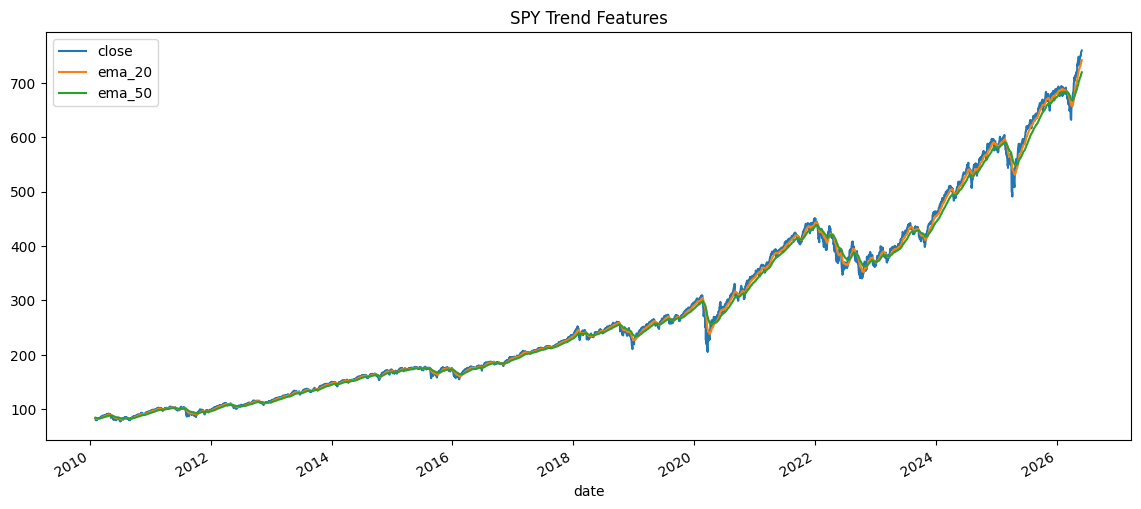

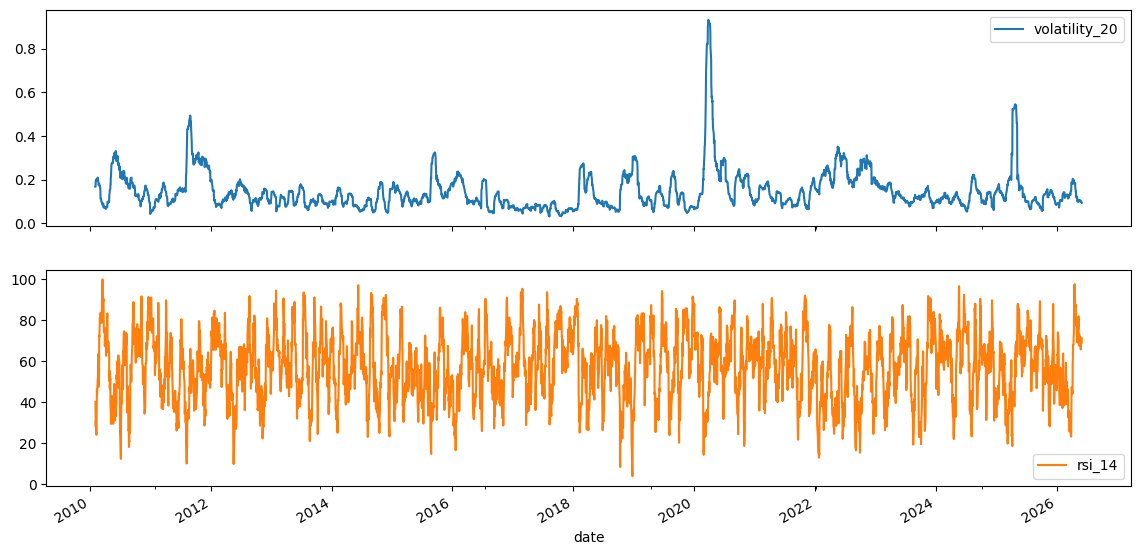

In [5]:
dataset.plot(x="date", y=["close", "ema_20", "ema_50"], figsize=(14, 6), title="SPY Trend Features")
plt.show()

dataset.plot(x="date", y=["volatility_20", "rsi_14"], subplots=True, figsize=(14, 7))
plt.show()